In [3]:
import os
import sys
# Get the root directory (parent of 'notebooks/')
root_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(root_dir)

In [4]:
from model import train

In [5]:
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import transformers
from sklearn.manifold import TSNE

In [6]:
CHECKPOINT = "huggingface/CodeBERTa-small-v1"

In [8]:
bert = transformers.AutoModel.from_pretrained(CHECKPOINT)
bert_tokenizer = transformers.AutoTokenizer.from_pretrained(CHECKPOINT)

In [10]:
path = "/home/peter/Downloads/codesim_models/CLS_pooling_new_dataset_10_epochs_infoNCE/model.pt"
model = train.CodeSimSBertTripletENC(bert)
#model.load_state_dict(torch.load(path, map_location=torch.device('cpu')))
model.eval()

CodeSimSBertTripletENC(
  (bert): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(52000, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-5): 6 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): L

In [11]:
data = pd.read_csv("/home/peter/repos/CodeSim/dataset/output_large.csv")
data

,problem_id,submission_id,status,code
0,p03711,s543499340,Accepted,"x, y = map(int, input().split())\na = [1,3,5,7..."
1,p03711,s354804624,Accepted,"x, y = map(int, input().split())\na = [2]\nb =..."
2,p03711,s945585026,Accepted,"l1 = [1,3,5,7,8,10,12]\nl2 = [4,6,9,11]\nl3 = ..."
3,p03711,s767362367,Accepted,"x,y = map(int, input().split())\nA = [1,3,5,7,..."
4,p03711,s594100945,Accepted,"x, y = map(int, input().split())\n\nlist_1 = [..."
...,...,...,...,...
128395,p03261,s583865019,Wrong Answer,N = int(input())\nW = [input() for i in range(...
128396,p03261,s627756319,Wrong Answer,N = int(input())\nW = []\nfor i in range(N):\n...
128397,p03261,s206613132,Wrong Answer,n=int(input())\na=[]\nfor n in range(n):\n a....
128398,p03261,s522444501,Wrong Answer,N = int(input())\nW = [input() for i in range(...


In [12]:
train_df, valid_df, test_df = train.code_sim_datasets.split_df(data)
test_df

,problem_id,submission_id,status,code
0,p02957,s799365635,Accepted,"A,B = map(int,input().split())\nN = A+B\n\nif ..."
1,p03796,s192773874,Wrong Answer,INF = 10**7 + 7\n\nN = int(input())\npower = 1...
2,p03309,s527090882,Accepted,#coding: utf-8\nimport math\nimport heapq\nimp...
3,p03860,s573700277,Accepted,a = input().split()\ns = a[1][0]\nans = 'A' + ...
4,p03761,s650372064,Accepted,n = int(input())\ns = [input() for _ in range(...
...,...,...,...,...
12835,p03836,s335858471,Accepted,"sx,sy,tx,ty = map(int,input().split())\nprint(..."
12836,p02900,s911537671,Accepted,"import fractions\na,b=map(int,input().split())..."
12837,p02917,s792747082,Accepted,n = int(input())\nb = [int(_) for _ in input()...
12838,p02608,s047282668,Accepted,import collections\n\nn = int(input())\nans_li...


In [13]:
test_df.value_counts("status")

status
Accepted        9416
Wrong Answer    3424
Name: count, dtype: int64

In [14]:
test_df.value_counts("problem_id")

problem_id
p02546    30
p03371    30
p03359    30
p03352    30
p03351    30
          ..
p02802    30
p02801    30
p02797    30
p02796    30
p04045    30
Name: count, Length: 428, dtype: int64

In [15]:
def get_samples_to_plot(df: pd.DataFrame, num_samples=20, num_problems=13):

    samples = {}
    statuses = {}
    for i, (group, group_df) in enumerate(df.groupby("problem_id")):
        print(f"Group: {group}")
        sample = group_df.sample(num_samples, random_state=42)
        samples [group] = sample["code"]  .to_list()
        statuses[group] = sample["status"].to_list()
        if i > num_problems: break
    
    tokenize = \
        lambda code : bert_tokenizer(code, padding=True, truncation=True, return_tensors="pt")
    
    samples_enc = {}

    for problem in samples:
        for code in samples[problem]:
            samples_enc[problem] = tokenize(samples[problem])
    
    samples_emb = {}

    for problem in samples_enc:
        with torch.no_grad():  embeddings = model(samples_enc[problem])
        samples_emb[problem] = embeddings
    
    embs = []
    lbls = []
    stss = []  # statuses

    for label, tensors in samples_emb.items():
        for i, tensor in enumerate(tensors):
            embs.append(tensor.detach().cpu().numpy())
            lbls.append(label)
            stss.append(statuses[label][i])
    
    return embs, lbls, stss
    

In [16]:
embs_1, lbls_1, stss_1 = get_samples_to_plot(test_df)
tsne_1 = TSNE(n_components=2, random_state=42)
reduced_embeddings_1 = tsne_1.fit_transform(np.stack(embs_1))

Group: p02546
Group: p02547
Group: p02548
Group: p02552
Group: p02553
Group: p02554
Group: p02555
Group: p02556
Group: p02570
Group: p02571
Group: p02572
Group: p02576
Group: p02577
Group: p02578
Group: p02582


In [17]:
embs_2, lbls_2, stss_2 = get_samples_to_plot(train_df)
tsne_2 = TSNE(n_components=2, random_state=42)
reduced_embeddings_2 = tsne_2.fit_transform(np.stack(embs_2))

Group: p02546
Group: p02547
Group: p02548
Group: p02552
Group: p02553
Group: p02554
Group: p02555
Group: p02556
Group: p02570
Group: p02571
Group: p02572
Group: p02576
Group: p02577
Group: p02578
Group: p02582


In [19]:
def plot_reduced_embeddings(reduced_embeddings, problems, statuses, title):
    data = pd.DataFrame(reduced_embeddings, columns=['x','y'])
    data['problems'] = problems
    data["statuses"] = statuses
    markers = {"Wrong Answer": 'X', "Accepted": 'o'}

    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        data=data,
        x='x', y='y',
        hue='problems',
        style='statuses',
        markers=markers,
        s=100,
        edgecolor='black',
        legend='full'
    )
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

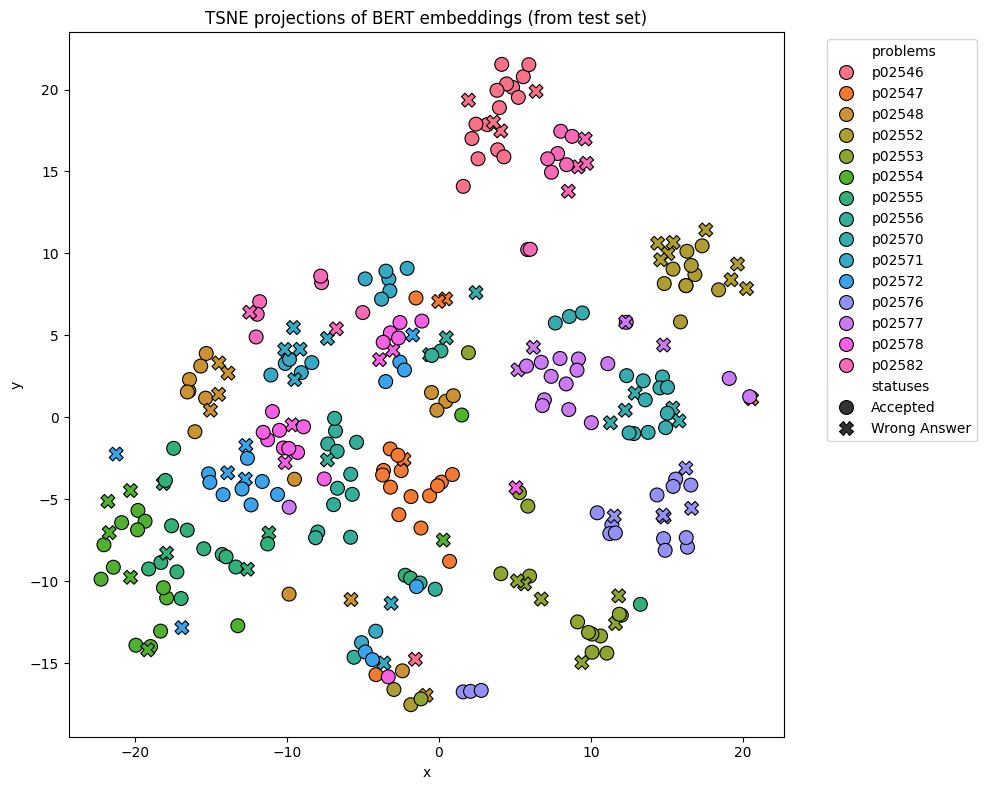

In [20]:
plot_reduced_embeddings(reduced_embeddings_1, lbls_1, stss_1,
                        "TSNE projections of BERT embeddings (from test set)")

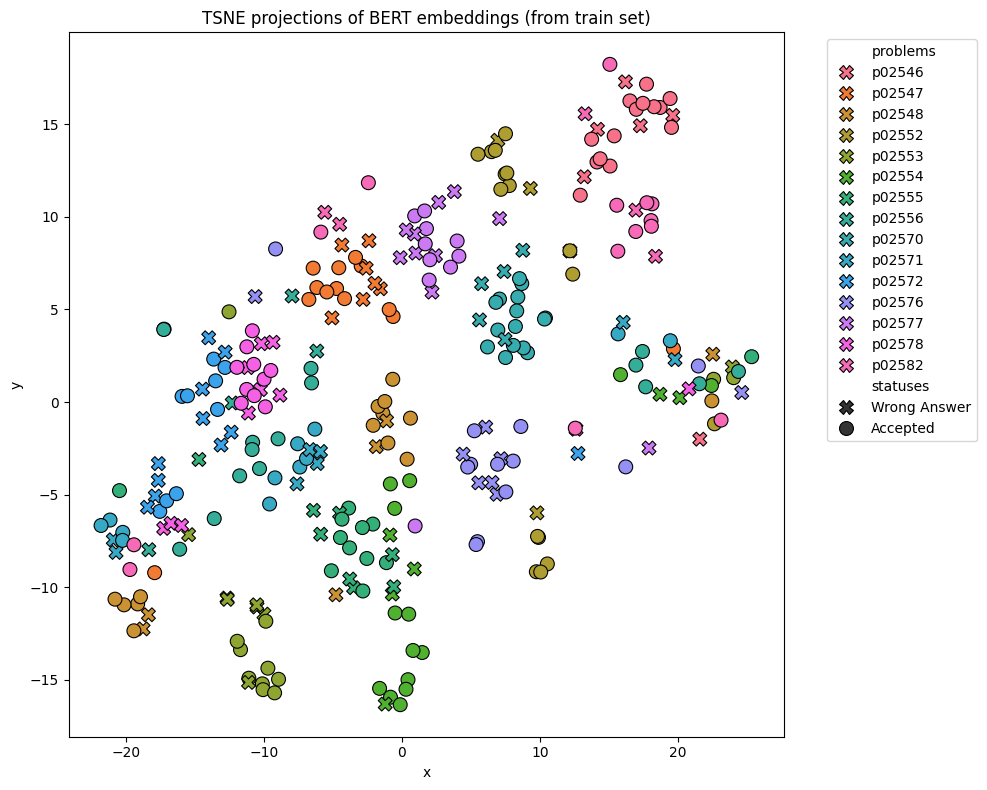

In [21]:
plot_reduced_embeddings(reduced_embeddings_2, lbls_2, stss_2,
                        "TSNE projections of BERT embeddings (from train set)")